# Phase diagrams and activity models

Txy, Pxy, xy and ternary LLE diagrams with `difflow.phase_diagrams`, and the Wilson, Margules and van Laar activity models (#398).

Validation notes: benzene-toluene end points match the normal boiling points; the ethanol-water NRTL azeotrope is x = 0.893, 351.29 K (experiment 0.894, 351.3 K). The Wilson methanol-water parameters are *regressed* to a Txy table, not independently published constants.

In [1]:
import jax, jax.numpy as jnp
import matplotlib.pyplot as plt
jax.config.update("jax_enable_x64", True)
from difflow import (IdealThermo, NRTLParams, WilsonParams, VanLaarParams, txy, pxy, xy_curve,
                     find_azeotrope, ternary_lle, bubble_T)
from difflow.database import get_species_data
from difflow.thermo import SpeciesData
from difflow.visualization import plot_txy, plot_pxy, plot_xy, plot_ternary

## Benzene-toluene (Raoult)

end points (K): 353.2529123454053 383.7730938223505  mean alpha: 2.4852738005422097


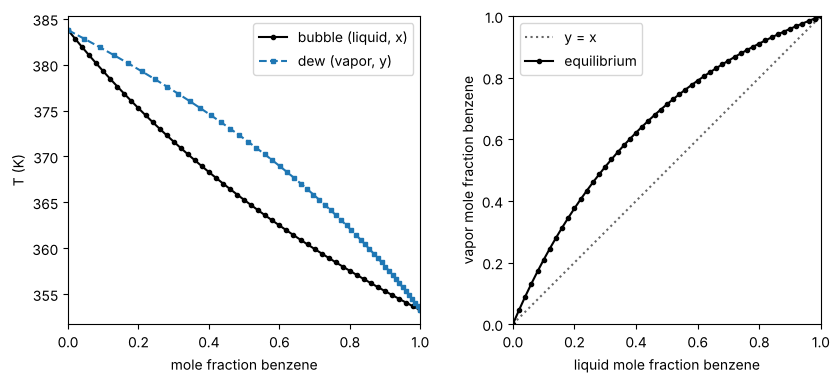

In [2]:
bt = IdealThermo({s: get_species_data(s) for s in ("benzene", "toluene")})
sp = ["benzene", "toluene"]
d = txy(bt, sp, 101325.0)
a = xy_curve(bt, sp, 101325.0)
print("end points (K):", float(d["T"][-1]), float(d["T"][0]), " mean alpha:", float(a["alpha"].mean()))
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
plot_txy(d, axs[0]); plot_xy(a, axs[1]); plt.show()

## Ethanol-water with NRTL: azeotrope

Antoine (NIST, log10 P/bar shifted +5 for Pa) and the DECHEMA/Aspen NRTL set (alpha = 0.3).

{'found': 1.0, 'x': 0.8934426547979998, 'T': 351.2889486063289, 'P': 101325.0}


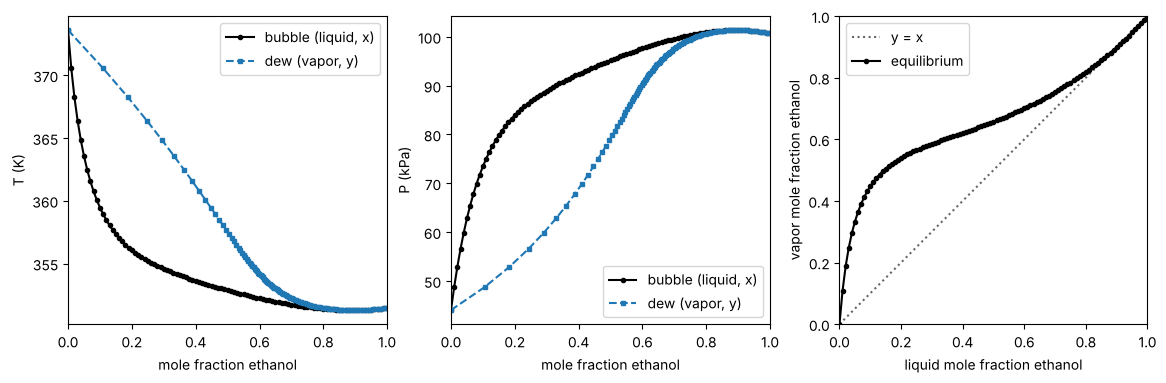

In [3]:
def sd(name, antoine, Tc):
    return SpeciesData(name=name, MW=1.0, Cp_coeffs=(0,0,0,0), Hvap_coeffs=(1.0,0.38,Tc), antoine_coeffs=antoine)
ew = IdealThermo({"ethanol": sd("ethanol", (10.24677, 1598.673, -46.424), 514.0),
                  "water": sd("water", (9.6543, 1435.264, -64.848), 647.0)})
nrtl = NRTLParams(("ethanol", "water"),
                  a=jnp.array([[0, -0.8009], [3.4578, 0]]), b=jnp.array([[0, 246.18], [-586.0809, 0]]),
                  alpha=jnp.array([[0, .3], [.3, 0]]))
spe = ["ethanol", "water"]
az = find_azeotrope(ew, spe, P=101325.0, activity_model=nrtl)
print({k: float(v) for k, v in az.items() if k != "species"})
fig, axs = plt.subplots(1, 3, figsize=(14, 4))
plot_txy(txy(ew, spe, 101325.0, 101, nrtl), axs[0])
plot_pxy(pxy(ew, spe, 351.3, 101, nrtl), axs[1])
plot_xy(xy_curve(ew, spe, 101325.0, 101, nrtl), axs[2]); plt.show()

## Gradients: azeotrope temperature vs. pressure

The diagrams are differentiable (implicit differentiation through the bubble-T solve).

In [4]:
f = lambda P: find_azeotrope(ew, spe, P=P, activity_model=nrtl)["T"]
print("dT_az/dP (K/kPa):", float(jax.grad(f)(101325.0)) * 1e3)
vl = VanLaarParams(("ethanol", "water"), 1.6798, 0.9227)
print("van Laar azeotrope:", {k: float(v) for k, v in find_azeotrope(ew, spe, P=101325.0, activity_model=vl).items() if k in ("x", "T")})

dT_az/dP (K/kPa): 0.24907017217185382


van Laar azeotrope: {'x': 0.9114187875237992, 'T': 351.3439325068207}


## Wilson, methanol-water

The model drops into `Flash(activity_model=...)` and the diagram helpers alike.

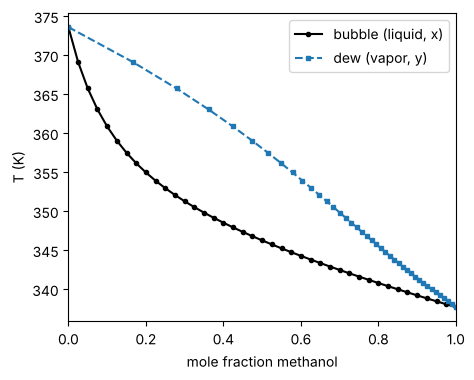

In [5]:
mw = IdealThermo({"methanol": sd("methanol", (10.20409, 1581.341, -33.5), 512.6),
                  "water": sd("water", (9.6543, 1435.264, -64.848), 647.0)})
wil = WilsonParams.binary(("methanol", "water"), [40.73e-6, 18.07e-6], 667.0, 1981.0)
dm = txy(mw, ["methanol", "water"], 101325.0, 41, wil)
plot_txy(dm); plt.show()

## Ternary LLE

Synthetic type-I NRTL system (species a, b partially miscible; s the solute).

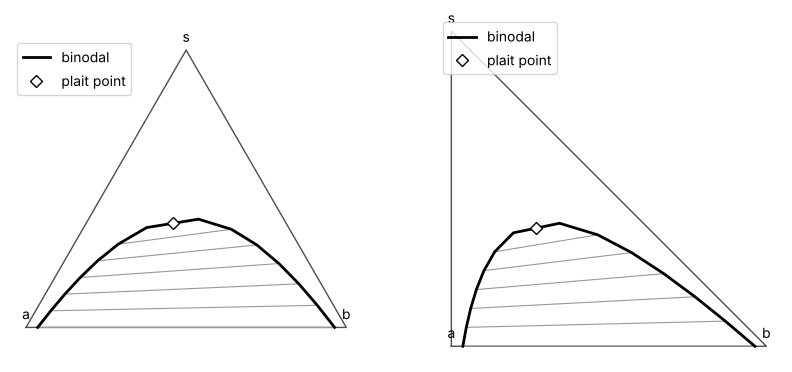

In [6]:
tau = jnp.array([[0.0, 2.5, 0.5], [2.5, 0.0, 0.3], [0.8, 0.6, 0.0]])
tern = NRTLParams(("a", "b", "s"), tau, jnp.zeros((3, 3)), 0.3 * (1 - jnp.eye(3)))
lle = ternary_lle(tern, 300.0, n_tie=10)
fig, axs = plt.subplots(1, 2, figsize=(10, 4.5))
plot_ternary(lle, axs[0], labels=("a", "b", "s"))
plot_ternary(lle, axs[1], coords="right", labels=("a", "b", "s")); plt.show()